## CUSTOMER CHURN ANALYSIS AND PREDICTION


In [95]:
import numpy as np 
import pandas as pd

In [96]:
df=pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [97]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [98]:
df.shape

(7043, 21)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [100]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [101]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [102]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [103]:
df["TotalCharges"].dtype

dtype('O')

In [104]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [105]:
df["TotalCharges"].dtype

dtype('float64')

In [106]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [107]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [108]:
df["TotalCharges"].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [109]:
df.groupby("SeniorCitizen")["Churn"].value_counts()

SeniorCitizen  Churn
0              No       4508
               Yes      1393
1              No        666
               Yes       476
Name: count, dtype: int64

In [110]:
df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True) * 100

SeniorCitizen  Churn
0              No       76.393832
               Yes      23.606168
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64

In [111]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [112]:
df.groupby("SeniorCitizen")["Churn"].mean() * 100

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

In [113]:
df = df.drop("customerID", axis=1)

In [114]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [115]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [116]:
X.shape

(7043, 19)

In [117]:
y.shape

(7043,)

In [118]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object"]).columns

In [119]:
print(numerical_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [120]:
print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [121]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [122]:
X_train.shape

(5634, 19)

In [123]:
X_test.shape

(1409, 19)

In [124]:
y_train.shape

(5634,)

In [125]:
y_test.shape

(1409,)

In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [127]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

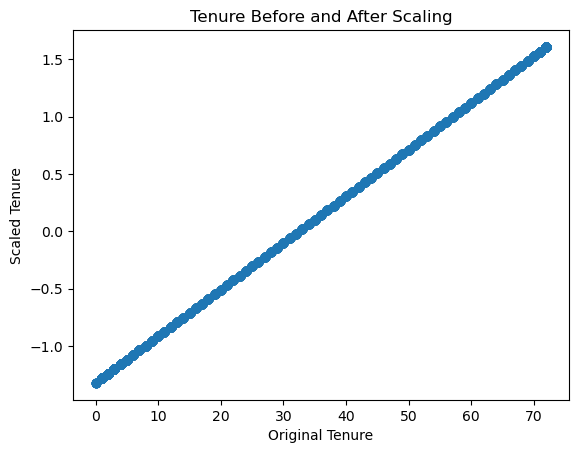

In [128]:
import matplotlib.pyplot as plt

scaler = StandardScaler()
tenure_scaled = scaler.fit_transform(X_train[["tenure"]])
plt.scatter(X_train["tenure"], tenure_scaled)
plt.title("Tenure Before and After Scaling")
plt.xlabel("Original Tenure")
plt.ylabel("Scaled Tenure")
plt.show()

In [129]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [130]:
logistic_model = Pipeline(steps=[("preprocessor", preprocessor), ("model", LogisticRegression(random_state=42, class_weight="balanced"))])

In [131]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [132]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [133]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [134]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr) * 100)
print("Precision:", precision_score(y_test, y_pred_lr) * 100)
print("Recall:", recall_score(y_test, y_pred_lr) * 100)
print("F1 Score:", f1_score(y_test, y_pred_lr) * 100)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr) * 100)

Accuracy: 73.81121362668559
Precision: 50.4302925989673
Recall: 78.34224598930481
F1 Score: 61.361256544502616
ROC-AUC: 84.12978893797307


In [135]:
from sklearn.ensemble import RandomForestClassifier

In [136]:
random_forest_model = Pipeline(steps=[("preprocessor", preprocessor), ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))])

In [137]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [138]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [141]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf) * 100)
print("Precision:", precision_score(y_test, y_pred_rf) * 100)
print("Recall:", recall_score(y_test, y_pred_rf) * 100)
print("F1 Score:", f1_score(y_test, y_pred_rf) * 100)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf) * 100)

Accuracy: 78.42441447835344
Precision: 62.323943661971825
Recall: 47.32620320855615
F1 Score: 53.799392097264445
ROC-AUC: 81.93249631868558


In [142]:
from xgboost import XGBClassifier

In [143]:
no_churn = y_train.value_counts()[0]
churn = y_train.value_counts()[1]
scale_pos_weight = no_churn / churn
print("No churn:", no_churn)
print("Churn:", churn)
print("Scale pos weight:", scale_pos_weight)

No churn: 4139
Churn: 1495
Scale pos weight: 2.768561872909699


In [144]:
xgb_model = Pipeline(steps=[("preprocessor", preprocessor), ("model", XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight))])

In [145]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtect...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [146]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [147]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.752306600425834
Precision: 0.5263157894736842
Recall: 0.6684491978609626
F1 Score: 0.5889281507656066
ROC-AUC: 0.8187165775401068


In [148]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb)],
    "F1 Score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf), roc_auc_score(y_test, y_prob_xgb)]
})

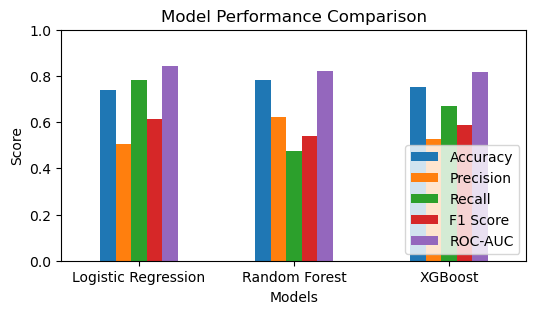

In [149]:

results.set_index("Model").plot(kind="bar", figsize=(6, 3))

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [150]:
results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841298
1,Random Forest,0.784244,0.623239,0.473262,0.537994,0.819325
2,XGBoost,0.752307,0.526316,0.668449,0.588928,0.818717


In [151]:
final_model = logistic_model

In [153]:
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]


In [154]:

import joblib
joblib.dump(final_model, "customer_churn_logistic_regression_model.pkl")

print("Final Logistic Regression model saved successfully.")

Final Logistic Regression model saved successfully.


In [155]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred_final))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion Matrix:
[[747 288]
 [ 81 293]]


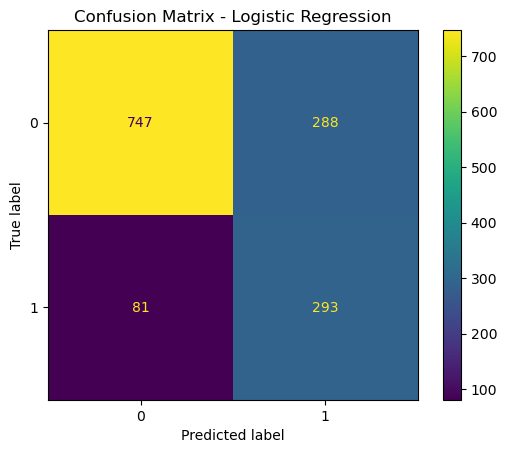

In [156]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

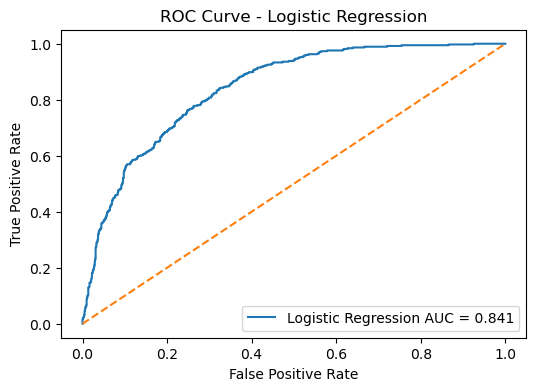

In [157]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
auc_score = roc_auc_score(y_test, y_prob_final)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()